In [ ]:
import os 
import json
import numpy as np
import polars as pl
from movedb.core import Trial
from movedb.file_io import sto_to_df
from src.grouping import trim_and_spline
root_dir = os.path.join('C:\\', 'Users', 'hpb7kr', 'OneDrive - University of Virginia', 'Shared Documents - MAMP Lab Folder', 'General', 'MoCapData', 'ViconData', 'Rats')

# Process all control group results
print("Processing control group results...")
control_results_file = os.path.join(root_dir, 'control_group_results.json')
old_results_file = os.path.join(root_dir, 'old_group_results.json')


with open(control_results_file, 'r') as f:
    control_results = json.load(f)

with open(old_results_file, 'r') as f:
    old_results = json.load(f)



stance_gait_pct = pl.Series('gait_percentage', np.linspace(0, 50, 100))
swing_gait_pct = pl.Series('gait_percentage', np.linspace(50, 100, 100))

left_stance_swing = [
    ('Left', 'Foot Strike'),
    ('Right', 'Foot Off'),
    ('Right', 'Foot Strike'),
    ('Left', 'Foot Off'),
    ('Left', 'Foot Strike'),
    ('Right', 'Foot Off'),
    ('Right', 'Foot Strike'),
]

right_stance_swing = [
    ('Right', 'Foot Strike'),
    ('Left', 'Foot Off'),
    ('Left', 'Foot Strike'),
    ('Right', 'Foot Off'),
    ('Right', 'Foot Strike'),
    ('Left', 'Foot Off'),
    ('Left', 'Foot Strike'),
]
control_ik = {"Left": [], "Right": []}
control_id = {"Left": [], "Right": []}
old_ik = {"Left": [], "Right": []}
old_id = {"Left": [], "Right": []}

# Process control group results
print("Processing control group results...")
for classification, subjects in control_results.items():
    for subject, sessions in subjects.items():
        for session, session_data in sessions.items():
            if session_data is None or not isinstance(session_data, dict):
                continue
            walking_trials = session_data.get('walking_trials', [])
            session_ik: dict[str, list[pl.DataFrame]]= {"Left": [], "Right": []}
            session_id: dict[str, list[pl.DataFrame]] = {"Left": [], "Right": []}
            session_grf: dict[str, list[pl.DataFrame]] = {"Left": [], "Right": []}
            for trial_pkl, files in walking_trials.items():
                ik_file = files.get('ik', None)
                id_file = files.get('id', None)
                fp_file = files.get('fp_mot', None)
                trial = Trial.from_pkl(trial_pkl)
                mass = trial.parameters.get('Mass', 0.1)
                # Spline to stance swing
                for side in ['Left', 'Right']:
                    phases = trial.get_event_sequences(right_stance_swing if side == 'Right' else left_stance_swing)
                    for phase in phases:
                        stance_phase = phase[:4]
                        swing_phase = phase[3:]
                        stance_times = [event.get_time(trial.points.rate) for event in stance_phase]
                        swing_times = [event.get_time(trial.points.rate) for event in swing_phase]
                        if ik_file:
                            try:
                                ik_df, _ = sto_to_df(ik_file)
                                # Trim and spline to exactly 100 points each for stance and swing
                                stance_ik = trim_and_spline(ik_df, start=stance_times[0], end=stance_times[-1], num_points=100)
                                swing_ik = trim_and_spline(ik_df, start=swing_times[0], end=swing_times[-1], num_points=100)
                                
                                stance_ik = stance_ik.with_columns(stance_gait_pct)
                                swing_ik = swing_ik.with_columns(swing_gait_pct)
                                
                                # Combine stance and swing (200 points total, 0-100% gait cycle)
                                spline_ik = pl.concat([stance_ik, swing_ik]).sort('gait_percentage')
                                session_ik[side].append(spline_ik)
                            except Exception as e:
                                print(f"Error processing IK file for {subject}, session {session}, trial {trial_pkl}: {e}")
                        if id_file:
                            try:
                                id_df, _ = sto_to_df(id_file)
                                # Trim and spline to exactly 100 points each for stance and swing
                                stance_id = trim_and_spline(id_df, start=stance_times[0], end=stance_times[-1], num_points=100)
                                swing_id = trim_and_spline(id_df, start=swing_times[0], end=swing_times[-1], num_points=100)
                                
                                # Normalize by mass (exclude time column)
                                stance_id = stance_id.with_columns(pl.exclude('time') / mass)
                                swing_id = swing_id.with_columns(pl.exclude('time') / mass)
                                
                                stance_id = stance_id.with_columns(stance_gait_pct)
                                swing_id = swing_id.with_columns(swing_gait_pct)
                                
                                # Combine stance and swing (200 points total, 0-100% gait cycle)
                                spline_id = pl.concat([stance_id, swing_id]).sort('gait_percentage')
                                session_id[side].append(spline_id)
                            except Exception as e:
                                print(f"Error processing ID file for {subject}, session {session}, trial {trial_pkl}: {e}")
            # Average the session data across trials
            for side in ['Left', 'Right']:
                if session_ik[side]:
                    combined_ik = pl.concat(session_ik[side])
                    # Get all numeric columns except 'gait_percentage' for averaging
                    numeric_cols = [col for col in combined_ik.columns if col != 'gait_percentage' and combined_ik[col].dtype.is_numeric()]
                    avg_ik = combined_ik.group_by('gait_percentage').agg([
                        pl.col(col).mean().alias(col) for col in numeric_cols
                    ]).sort('gait_percentage')
                    control_ik[side].append(avg_ik)
                # if session_id[side]:
                #     combined_id = pl.concat(session_id[side])
                #     # Get all numeric columns except 'gait_percentage' for averaging
                #     numeric_cols = [col for col in combined_id.columns if col != 'gait_percentage' and combined_id[col].dtype.is_numeric()]
                #     avg_id = combined_id.group_by('gait_percentage').agg([
                #         pl.col(col).mean().alias(col) for col in numeric_cols
                #     ]).sort('gait_percentage')
                #     control_id[side].append(avg_id)

# Process old group results  
print("Processing old group results...")
for classification, subjects in old_results.items():
    for subject, sessions in subjects.items():
        for session, session_data in sessions.items():
            if session_data is None or not isinstance(session_data, dict):
                continue
            walking_trials = session_data.get('walking_trials', [])
            session_ik: dict[str, list[pl.DataFrame]]= {"Left": [], "Right": []}
            session_id: dict[str, list[pl.DataFrame]] = {"Left": [], "Right": []}
            session_grf: dict[str, list[pl.DataFrame]] = {"Left": [], "Right": []}
            for trial_pkl, files in walking_trials.items():
                ik_file = files.get('ik', None)
                id_file = files.get('id', None)
                grf_file = files.get('grf', None)
                trial = Trial.from_pkl(trial_pkl)
                mass = trial.parameters.get('Mass', 0.1)
                # Spline to stance swing
                for side in ['Left', 'Right']:
                    phases = trial.get_event_sequences(right_stance_swing if side == 'Right' else left_stance_swing)
                    for phase in phases:
                        stance_phase = phase[:4]
                        swing_phase = phase[3:]
                        stance_times = [event.get_time(trial.points.rate) for event in stance_phase]
                        swing_times = [event.get_time(trial.points.rate) for event in swing_phase]
                        if ik_file:
                            try:
                                ik_df, _ = sto_to_df(ik_file)
                                # Trim and spline to exactly 100 points each for stance and swing
                                stance_ik = trim_and_spline(ik_df, start=stance_times[0], end=stance_times[-1], num_points=100)
                                swing_ik = trim_and_spline(ik_df, start=swing_times[0], end=swing_times[-1], num_points=100)
                                
                                stance_ik = stance_ik.with_columns(stance_gait_pct)
                                swing_ik = swing_ik.with_columns(swing_gait_pct)
                                
                                # Combine stance and swing (200 points total, 0-100% gait cycle)
                                spline_ik = pl.concat([stance_ik, swing_ik]).sort('gait_percentage')
                                session_ik[side].append(spline_ik)
                            except Exception as e:
                                print(f"Error processing IK file for {subject}, session {session}, trial {trial_pkl}: {e}")
                        if id_file:
                            try:
                                id_df, _ = sto_to_df(id_file)
                                # Trim and spline to exactly 100 points each for stance and swing
                                stance_id = trim_and_spline(id_df, start=stance_times[0], end=stance_times[-1], num_points=100)
                                swing_id = trim_and_spline(id_df, start=swing_times[0], end=swing_times[-1], num_points=100)
                                
                                # Normalize by mass (exclude time column)
                                stance_id = stance_id.with_columns(pl.exclude('time') / mass)
                                swing_id = swing_id.with_columns(pl.exclude('time') / mass)
                                
                                stance_id = stance_id.with_columns(stance_gait_pct)
                                swing_id = swing_id.with_columns(swing_gait_pct)
                                
                                # Combine stance and swing (200 points total, 0-100% gait cycle)
                                spline_id = pl.concat([stance_id, swing_id]).sort('gait_percentage')
                                session_id[side].append(spline_id)
                            except Exception as e:
                                print(f"Error processing ID file for {subject}, session {session}, trial {trial_pkl}: {e}")
            # Average the session data across trials
            for side in ['Left', 'Right']:
                if session_ik[side]:
                    # Find common columns across all DataFrames before concatenation
                    common_cols = set(session_ik[side][0].columns)
                    for df in session_ik[side][1:]:
                        common_cols = common_cols.intersection(set(df.columns))
                    common_cols = list(common_cols)
                    
                    # Select only common columns for concatenation
                    aligned_dfs = [df.select(common_cols) for df in session_ik[side]]
                    combined_ik = pl.concat(aligned_dfs)
                    
                    # Get all numeric columns except 'gait_percentage' for averaging
                    numeric_cols = [col for col in combined_ik.columns if col != 'gait_percentage' and combined_ik[col].dtype.is_numeric()]
                    avg_ik = combined_ik.group_by('gait_percentage').agg([
                        pl.col(col).mean().alias(col) for col in numeric_cols
                    ]).sort('gait_percentage')
                    old_ik[side].append(avg_ik)

Processing control group results...
Processing control group results...


ShapeError: unable to append to a DataFrame of width 29 with a DataFrame of width 20

Calculating overall statistics for IK data...
Control Left side: 64 sessions, 23 joint angles
Control Right side: 73 sessions, 23 joint angles
Old Left side: 3 sessions, 23 joint angles
Old Right side: 2 sessions, 23 joint angles
Creating comparison plots for 13 joints...


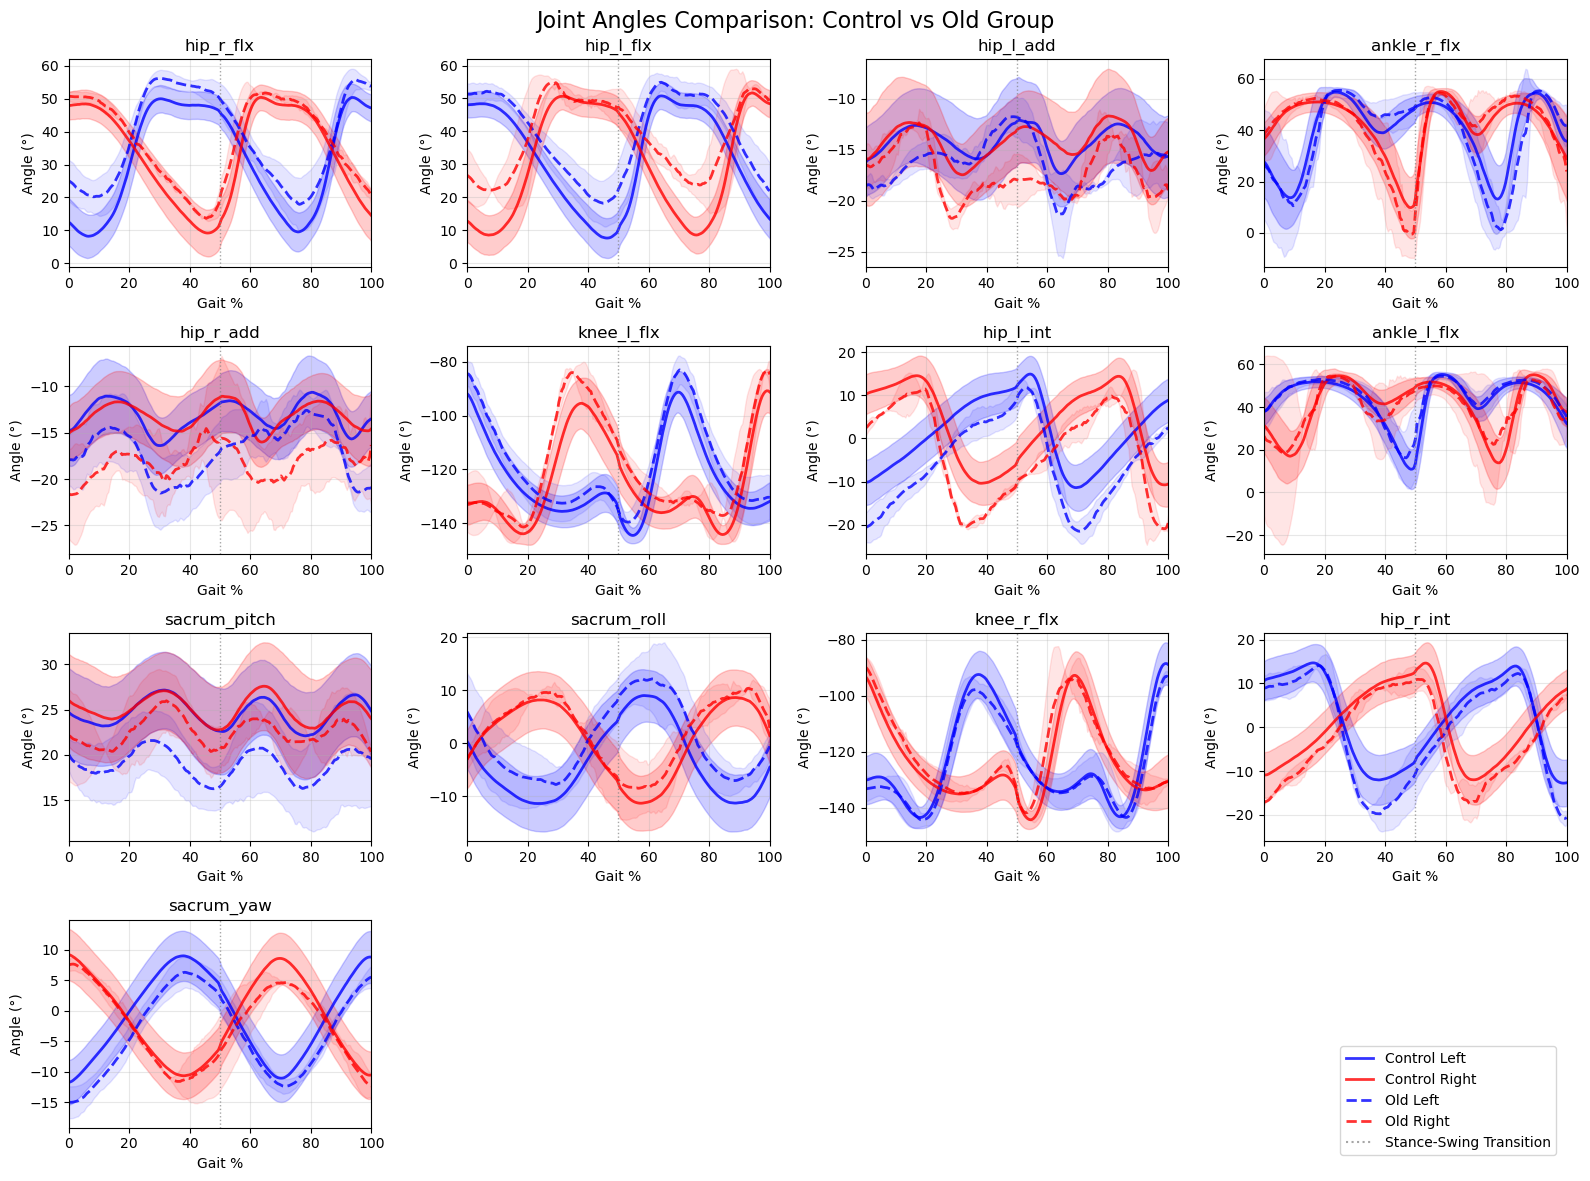

Plotting complete!


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate overall averages and standard deviations across all sessions
print("Calculating overall statistics for IK data...")

overall_control_stats = {"Left": None, "Right": None}
overall_old_stats = {"Left": None, "Right": None}

# Process control group
for side in ['Left', 'Right']:
    if control_ik[side]:
        # Find common columns across all session DataFrames before concatenation
        common_cols = set(control_ik[side][0].columns)
        for df in control_ik[side][1:]:
            common_cols = common_cols.intersection(set(df.columns))
        common_cols = list(common_cols)
        
        # Select only common columns for concatenation
        aligned_dfs = [df.select(common_cols) for df in control_ik[side]]
        all_sessions_ik = pl.concat(aligned_dfs)
        
        # Calculate overall mean and std across all sessions
        numeric_cols = [col for col in all_sessions_ik.columns if col != 'gait_percentage' and all_sessions_ik[col].dtype.is_numeric()]
        
        overall_mean = all_sessions_ik.group_by('gait_percentage').agg([
            pl.col(col).mean().alias(f"{col}_mean") for col in numeric_cols
        ]).sort('gait_percentage')
        
        overall_std = all_sessions_ik.group_by('gait_percentage').agg([
            pl.col(col).std().alias(f"{col}_std") for col in numeric_cols
        ]).sort('gait_percentage')
        
        # Combine mean and std
        overall_stats = overall_mean.join(overall_std, on='gait_percentage')
        overall_control_stats[side] = overall_stats
        
        print(f"Control {side} side: {len(control_ik[side])} sessions, {len(numeric_cols)} joint angles")

# Process old group
for side in ['Left', 'Right']:
    if old_ik[side]:
        # Find common columns across all session DataFrames before concatenation
        common_cols = set(old_ik[side][0].columns)
        for df in old_ik[side][1:]:
            common_cols = common_cols.intersection(set(df.columns))
        common_cols = list(common_cols)
        
        # Select only common columns for concatenation
        aligned_dfs = [df.select(common_cols) for df in old_ik[side]]
        all_sessions_ik = pl.concat(aligned_dfs)
        
        # Calculate overall mean and std across all sessions
        numeric_cols = [col for col in all_sessions_ik.columns if col != 'gait_percentage' and all_sessions_ik[col].dtype.is_numeric()]
        
        overall_mean = all_sessions_ik.group_by('gait_percentage').agg([
            pl.col(col).mean().alias(f"{col}_mean") for col in numeric_cols
        ]).sort('gait_percentage')
        
        overall_std = all_sessions_ik.group_by('gait_percentage').agg([
            pl.col(col).std().alias(f"{col}_std") for col in numeric_cols
        ]).sort('gait_percentage')
        
        # Combine mean and std
        overall_stats = overall_mean.join(overall_std, on='gait_percentage')
        overall_old_stats[side] = overall_stats
        
        print(f"Old {side} side: {len(old_ik[side])} sessions, {len(numeric_cols)} joint angles")

# Create comparison plots for each joint
sample_side = None
for side in ['Left', 'Right']:
    if overall_control_stats[side] is not None or overall_old_stats[side] is not None:
        sample_side = side
        break

if sample_side is not None:
    # Filter out unwanted columns
    exclude_cols = [
        'time', 'sacrum_x', 'sacrum_y', 'sacrum_z', 
        'sacroiliac_r_flx', 'sacroiliac_l_flx', 
        'ankle_l_add', 'ankle_l_int', 'ankle_r_add', 'ankle_r_int'
    ]
    
    # Get all available joint columns from both groups
    all_mean_cols = set()
    if overall_control_stats[sample_side] is not None:
        all_mean_cols.update([col for col in overall_control_stats[sample_side].columns if col.endswith('_mean')])
    if overall_old_stats[sample_side] is not None:
        all_mean_cols.update([col for col in overall_old_stats[sample_side].columns if col.endswith('_mean')])
    
    mean_cols = [col for col in all_mean_cols if col.replace('_mean', '') not in exclude_cols]
    n_joints = len(mean_cols)
    
    print(f"Creating comparison plots for {n_joints} joints...")
    
    # Calculate subplot layout
    n_cols = min(4, n_joints)
    n_rows = (n_joints + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(4*n_cols, 3*n_rows))
    fig.suptitle('Joint Angles Comparison: Control vs Old Group', fontsize=16)
    
    if n_rows == 1:
        axes = axes.reshape(1, -1)
    elif n_cols == 1:
        axes = axes.reshape(-1, 1)
    
    for joint_idx, mean_col in enumerate(mean_cols):
        row = joint_idx // n_cols
        col = joint_idx % n_cols
        ax = axes[row, col]
        
        joint_name = mean_col.replace('_mean', '')
        
        # Plot control group data
        for side in ['Left', 'Right']:
            if overall_control_stats[side] is not None:
                stats_df = overall_control_stats[side]
                std_col = f"{joint_name}_std"
                
                if mean_col in stats_df.columns and std_col in stats_df.columns:
                    gait_pct = stats_df['gait_percentage'].to_numpy()
                    mean_vals = stats_df[mean_col].to_numpy()
                    std_vals = stats_df[std_col].to_numpy()
                    
                    color = 'blue' if side == 'Left' else 'red'
                    
                    # Plot mean line (solid for control)
                    ax.plot(gait_pct, mean_vals, color=color, linewidth=2, 
                           linestyle='-', label=f'Control {side}', alpha=0.8)
                    
                    # Plot standard deviation as shaded area
                    ax.fill_between(gait_pct, mean_vals - std_vals, mean_vals + std_vals, 
                                   color=color, alpha=0.2)
        
        # Plot old group data
        for side in ['Left', 'Right']:
            if overall_old_stats[side] is not None:
                stats_df = overall_old_stats[side]
                std_col = f"{joint_name}_std"
                
                if mean_col in stats_df.columns and std_col in stats_df.columns:
                    gait_pct = stats_df['gait_percentage'].to_numpy()
                    mean_vals = stats_df[mean_col].to_numpy()
                    std_vals = stats_df[std_col].to_numpy()
                    
                    color = 'blue' if side == 'Left' else 'red'
                    
                    # Plot mean line (dashed for old)
                    ax.plot(gait_pct, mean_vals, color=color, linewidth=2, 
                           linestyle='--', label=f'Old {side}', alpha=0.8)
                    
                    # Plot standard deviation as shaded area
                    ax.fill_between(gait_pct, mean_vals - std_vals, mean_vals + std_vals, 
                                   color=color, alpha=0.1)
        
        # Add vertical line to mark stance-swing transition
        ax.axvline(x=50, color='gray', linestyle=':', alpha=0.7, linewidth=1)
        
        ax.set_title(joint_name)
        ax.set_xlabel('Gait %')
        ax.set_ylabel('Angle (°)')
        ax.grid(True, alpha=0.3)
        ax.set_xlim(0, 100)
    
    # Hide empty subplots
    for joint_idx in range(n_joints, n_rows * n_cols):
        row = joint_idx // n_cols
        col = joint_idx % n_cols
        axes[row, col].set_visible(False)
    
    # Create external legend
    from matplotlib.lines import Line2D
    legend_elements = [
        Line2D([0], [0], color='blue', lw=2, linestyle='-', alpha=0.8, label='Control Left'),
        Line2D([0], [0], color='red', lw=2, linestyle='-', alpha=0.8, label='Control Right'),
        Line2D([0], [0], color='blue', lw=2, linestyle='--', alpha=0.8, label='Old Left'),
        Line2D([0], [0], color='red', lw=2, linestyle='--', alpha=0.8, label='Old Right'),
        Line2D([0], [0], color='gray', linestyle=':', alpha=0.7, label='Stance-Swing Transition')
    ]
    fig.legend(handles=legend_elements, loc='lower right', bbox_to_anchor=(0.98, 0.02))
    
    plt.tight_layout()
    plt.show()

print("Plotting complete!")